(524, 524, 3)


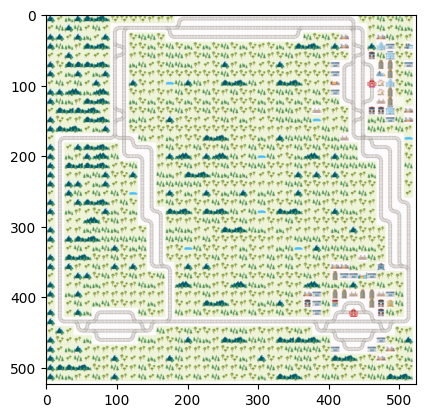

In [84]:
from flatland_tools.env import EnvGraph

import networkx as nx
import matplotlib.pyplot as plt
from flatland.envs.rail_env import RailEnv
from flatland.envs.rail_generators import sparse_rail_generator
from flatland.envs.line_generators import sparse_line_generator
from itertools import product
import matplotlib.colors as mcolors
import matplotlib as mpl
cmap = mpl.colormaps["tab20"]

# Create the environment
env = RailEnv(
    width=40,
    height=40,
    rail_generator=sparse_rail_generator(
        max_num_cities=4,
        grid_mode=True,
        max_rails_between_cities=2,
        max_rail_pairs_in_city=3,
        seed=43,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)
env.reset()
img = env.render()
print(img.shape)
plt.imshow(img)

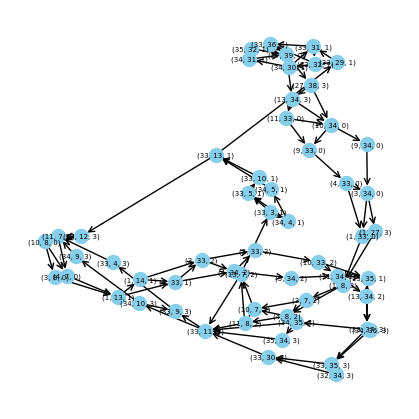

In [85]:
EnvGraph(env).render((4, 4))

100%|██████████| 6400/6400 [00:00<00:00, 108935.45it/s]


[((0, 14), {'transition': '0100000000000010', 'node_color': '#c5b0d5'}), ((0, 15), {'transition': '0000010000000001', 'node_color': '#c5b0d5'}), ((1, 14), {'transition': '0000110000010001', 'node_color': '#c5b0d5'}), ((0, 16), {'transition': '0000010000000001', 'node_color': '#2ca02c'}), ((0, 17), {'transition': '0000010000000001', 'node_color': '#9edae5'}), ((0, 18), {'transition': '0000010000000001', 'node_color': '#c7c7c7'}), ((0, 19), {'transition': '0000010000000001', 'node_color': '#bcbd22'}), ((0, 20), {'transition': '0000010000000001', 'node_color': '#ff7f0e'}), ((0, 21), {'transition': '0000010000000001', 'node_color': '#ffbb78'}), ((0, 22), {'transition': '0000010000000001', 'node_color': '#9467bd'}), ((0, 23), {'transition': '0000010000000001', 'node_color': '#d62728'}), ((0, 24), {'transition': '0000010000000001', 'node_color': '#98df8a'}), ((0, 25), {'transition': '0000010000000001', 'node_color': '#d62728'}), ((0, 26), {'transition': '0000010000000001', 'node_color': '#c7

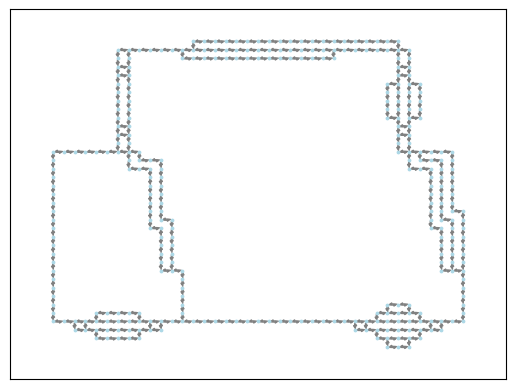

In [86]:
from tqdm import tqdm
import numpy as np

graph = nx.DiGraph()

get_txs = env.rail.get_transitions
for row, col, dir in tqdm(
    product(range(env.height), range(env.width), range(4)),
    total=env.height * env.width * 4,
):
    # [North, East, South, West]
    if bin(env.rail.get_full_transitions(row, col)).count("1") == 0:
        continue
    for dir_idx, tx in enumerate(get_txs(row, col, dir)):
        if tx == 0:
            continue
        # Find next cell coordinates
        next_row = row
        next_col = col
        if dir_idx == 0:  # North
            next_row -= 1
        elif dir_idx == 1:  # East
            next_col += 1
        elif dir_idx == 2:  # South
            next_row += 1
        else:  # West
            next_col -= 1

        # Check if next cell is within the grid
        if (
            next_row >= 0
            and next_row < env.width
            and next_col >= 0
            and next_col < env.height
        ):
            node_color = mcolors.to_hex(mcolors.to_rgba_array(cmap(np.random.randint(20))))
            if not graph.has_node((row, col)):
                graph.add_node(
                    (row, col),
                    transition=bin(env.rail.get_full_transitions(row, col))[2:].zfill(
                        16
                    ),
                    node_color=node_color
                )
            if not graph.has_node((next_row, next_col)):
                graph.add_node(
                    (next_row, next_col),
                    transition=bin(env.rail.get_full_transitions(next_row, next_col))[
                        2:
                    ].zfill(16),
                    node_color=node_color
                )

            graph.add_edge((row, col), (next_row, next_col))
print(graph.nodes.data())

pos = {node: np.array([node[1], -node[0]]) for node in graph.nodes()}
fig, ax = plt.subplots()
nx.draw_networkx(
    graph,
    pos,
    connectionstyle="arc3,rad=0.1",
    with_labels=False,
    node_color="lightblue",
    edge_color="gray",
    node_size=3,
    arrowsize=3,
    ax=ax,
)
print(pos)

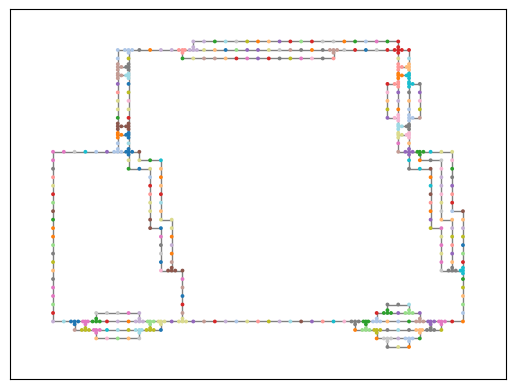

In [87]:
graph = graph.to_undirected()
new_nodes = set()
for node in list(graph.nodes):
    node_degree = graph.degree(node)
    if node_degree == 2:
        continue

    # add surrounding nodes
    for idx, neighbor in enumerate(list(graph.neighbors(node))):
        
        new_node = (node[0] + 0.1 * (idx + 1), node[1] + 0.1 * (idx + 1))
        if node == (30, 7):
            print(node, neighbor)
            print(new_node in new_nodes, neighbor in new_nodes)
        # if new_node in new_nodes or neighbor in new_nodes:
        #     continue
        new_nodes.add(new_node)
        graph.add_node(new_node, node_color=graph.nodes.data("node_color")[node])
        graph.add_edge(neighbor, new_node)
        graph.add_edge(node, new_node)
        graph.remove_edge(node, neighbor)
        pos[new_node] = (pos[neighbor] + 2 * pos[node]) / 3
    

nx.draw_networkx(
    graph,
    pos,
    node_color=dict(graph.nodes.data(data="node_color")).values(),
    # connectionstyle="arc3,rad=0.1",
    with_labels=False,
    edge_color="gray",
    node_size=3,
)

In [88]:
graph.nodes.data("node_color")[(0, 14)]

'#c5b0d5'

In [89]:
graph.nodes.data(data="node_color")

NodeDataView({(0, 14): '#c5b0d5', (0, 15): '#c5b0d5', (1, 14): '#c5b0d5', (0, 16): '#2ca02c', (0, 17): '#9edae5', (0, 18): '#c7c7c7', (0, 19): '#bcbd22', (0, 20): '#ff7f0e', (0, 21): '#ffbb78', (0, 22): '#9467bd', (0, 23): '#d62728', (0, 24): '#98df8a', (0, 25): '#d62728', (0, 26): '#c7c7c7', (0, 27): '#c7c7c7', (0, 28): '#ff7f0e', (0, 29): '#2ca02c', (0, 30): '#aec7e8', (0, 31): '#e377c2', (0, 32): '#2ca02c', (0, 33): '#d62728', (1, 33): '#d62728', (1, 7): '#aec7e8', (1, 8): '#aec7e8', (2, 7): '#aec7e8', (1, 9): '#7f7f7f', (2, 8): '#bcbd22', (1, 10): '#ff7f0e', (1, 11): '#c5b0d5', (1, 12): '#c5b0d5', (1, 13): '#ff9896', (2, 13): '#2ca02c', (1, 15): '#dbdb8d', (1, 16): '#ffbb78', (1, 17): '#1f77b4', (1, 18): '#98df8a', (1, 19): '#9467bd', (1, 20): '#9467bd', (1, 21): '#dbdb8d', (1, 22): '#c7c7c7', (1, 23): '#c49c94', (1, 24): '#7f7f7f', (1, 25): '#ff7f0e', (1, 26): '#7f7f7f', (1, 27): '#c49c94', (1, 28): '#c7c7c7', (2, 27): '#ff9896', (1, 29): '#d62728', (1, 30): '#1f77b4', (1, 31): '#

In [90]:
# nx.draw(nx.ego_graph(graph, (29, 7), 3), pos, with_labels=True)

NodeView(((1, 14), (1, 33), (1, 8), (1, 13), (1, 27), (3, 7), (3, 8), (3, 33), (3, 34), (4, 7), (4, 8), (4, 33), (4, 34), (5, 33), (5, 34), (9, 33), (9, 34), (10, 7), (10, 8), (10, 33), (10, 34), (11, 7), (11, 8), (11, 33), (11, 34), (13, 7), (13, 8), (13, 34), (13, 35), (27, 12), (27, 38), (27, 39), (32, 32), (32, 34), (33, 5), (33, 9), (33, 13), (33, 31), (33, 35), (33, 3), (33, 4), (34, 4), (33, 10), (33, 11), (34, 10), (33, 29), (33, 30), (34, 30), (33, 36), (33, 37), (34, 36), (34, 5), (34, 9), (34, 31), (34, 35), (35, 32), (35, 34), (1.1, 14.1), (1.2, 14.2), (1.3, 14.3), (1.1, 33.1), (1.2, 33.2), (1.3, 33.3), (1.4, 33.4), (1.1, 8.1), (1.2, 8.2), (1.3, 8.3), (1.1, 13.1), (1.2, 13.2), (1.3, 13.3), (1.1, 27.1), (1.2, 27.2), (1.3, 27.3), (3.1, 7.1), (3.2, 7.2), (3.3, 7.3), (3.1, 8.1), (3.2, 8.2), (3.3, 8.3), (3.1, 33.1), (3.2, 33.2), (3.3, 33.3), (3.1, 34.1), (3.2, 34.2), (3.3, 34.3), (4.1, 7.1), (4.2, 7.2), (4.3, 7.3), (4.1, 8.1), (4.2, 8.2), (4.3, 8.3), (4.1, 33.1), (4.2, 33.2), (4

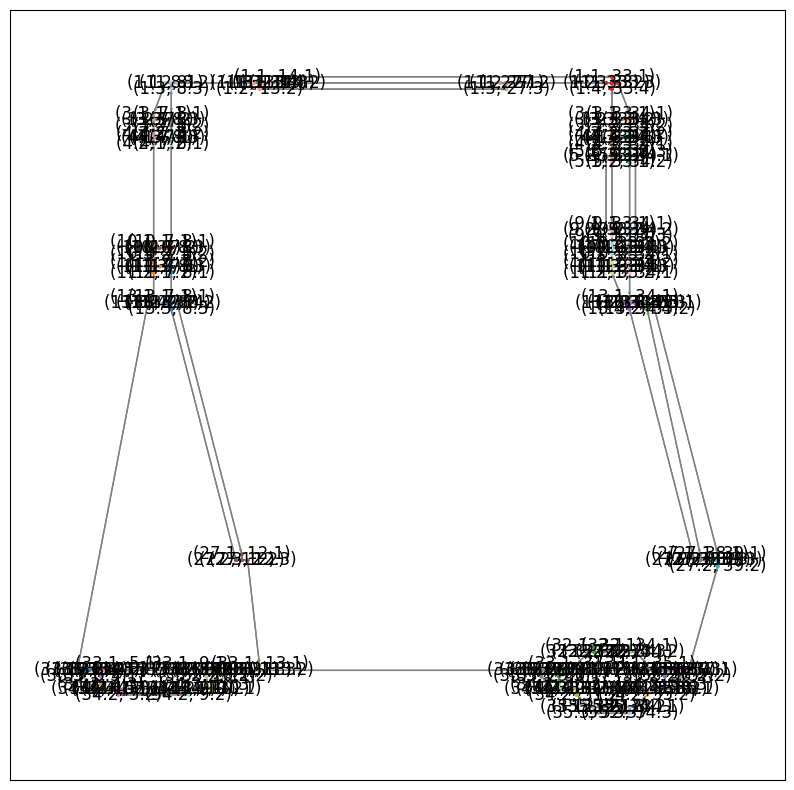

In [91]:
graph = graph.to_undirected()
for node in list(graph.nodes):
    node_degree = graph.degree(node)
    neighbors_degrees = set([graph.degree(n) for n in graph.neighbors(node)])
    if node_degree == 2 and neighbors_degrees == set([2]):
        prev_node, next_node = list(graph.neighbors(node))
        graph.remove_edge(prev_node, node)
        graph.remove_edge(node, next_node)
        graph.add_edge(prev_node, next_node)
        graph.remove_node(node)
graph = graph.to_directed()

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx(
    graph,
    pos,
    # connectionstyle="arc3,rad=0.1",
    with_labels=True,
    node_color=dict(graph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=4,
    arrowsize=3,
    ax=ax
)

graph.nodes

{(1, 0): 'E', (-1, 0): 'W', (0, 1): 'N', (0, -1): 'S'}


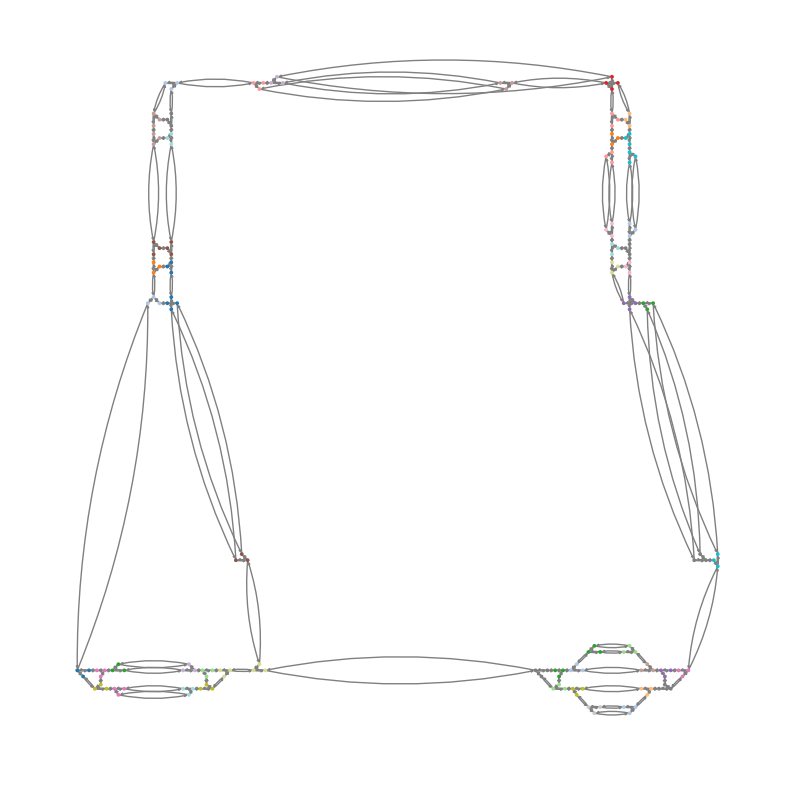

In [92]:
from itertools import combinations

rel_pos = [(1, 0), (-1, 0), (0, 1), (0, -1)]
directions = "EWNS"
directions = dict(zip(rel_pos, directions))
print(directions)
dir_combo = np.array(
    [
        "NN",
        "NE",
        "NS",
        "NW",
        "EN",
        "EE",
        "ES",
        "EW",
        "SN",
        "SE",
        "SS",
        "SW",
        "WN",
        "WE",
        "WS",
        "WW",
    ]
)

def find_in_degree_node(G: nx.DiGraph, k: int, rel = lambda x, y: x == 2) -> bool:
    res = [node for node in G.nodes if rel(G.in_degree(node), k)]
    return res
    
visited = set()
iter = 0
while True:
    nodes = find_in_degree_node(graph, 2, lambda x,y: x > y)
    if set(graph.nodes) == set(nodes) or set(node) == visited or (set(nodes) - visited) == set():
        break
    node = (set(nodes) - visited).pop()
    visited.add(node)
    
    allowed_transitions = graph.nodes[node]["transition"]
    switch_graph = graph.subgraph(nx.ego_graph(graph, node))
    if node == (39, 27):
        print(node)
    # get relative positions of the subgraphs
    for current_node, next_node in combinations(switch_graph.nodes, 2):
        if (
            current_node == node
            or next_node == node
            or not nx.tournament.is_reachable(switch_graph, current_node, next_node)
        ):
            continue
        visited.add(current_node)
        visited.add(next_node)
        train_facing = directions[tuple(np.sign((pos[node] - pos[current_node])).tolist())]
        train_going = directions[tuple(np.sign((pos[next_node] - pos[node])).tolist())]
        trans_idx = np.where(dir_combo == (train_facing + train_going))[0].item()
        if allowed_transitions[trans_idx] == "1":
            graph.add_edge(current_node, next_node)
        if node == (39, 27):
            print(current_node, next_node, train_facing + train_going)
            print(dir_combo[np.array(list(allowed_transitions), dtype=int).astype(bool)])

        train_facing = directions[tuple(np.sign((pos[node] - pos[next_node])).tolist())]
        train_going = directions[tuple(np.sign((pos[current_node] - pos[node])).tolist())]
        trans_idx = np.where(dir_combo == (train_facing + train_going))[0].item()
        if allowed_transitions[trans_idx] == "1":
            graph.add_edge(next_node, current_node)
        if node == (39, 27):
            print(current_node, next_node, train_facing + train_going)
            print(dir_combo[np.array(list(allowed_transitions), dtype=int).astype(bool)])

    graph.remove_node(node)
    # nx.draw(switch_graph, pos)
    # print(524 / 40 * pos[node][0], 524 / 40 * (pos[node][0] + 1))
    # plt.imshow(img[int(524 / 40 * node[0]): int(524 / 40 * (node[0] + 1)), int(524 / 40 * node[1]): int(524 / 40 * (node[1] + 1))])
    
   
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(
    graph,
    pos,
    connectionstyle="arc3,rad=0.1",
    with_labels=False,
    node_color=dict(graph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=3,
    arrowsize=3,
    ax=ax
)




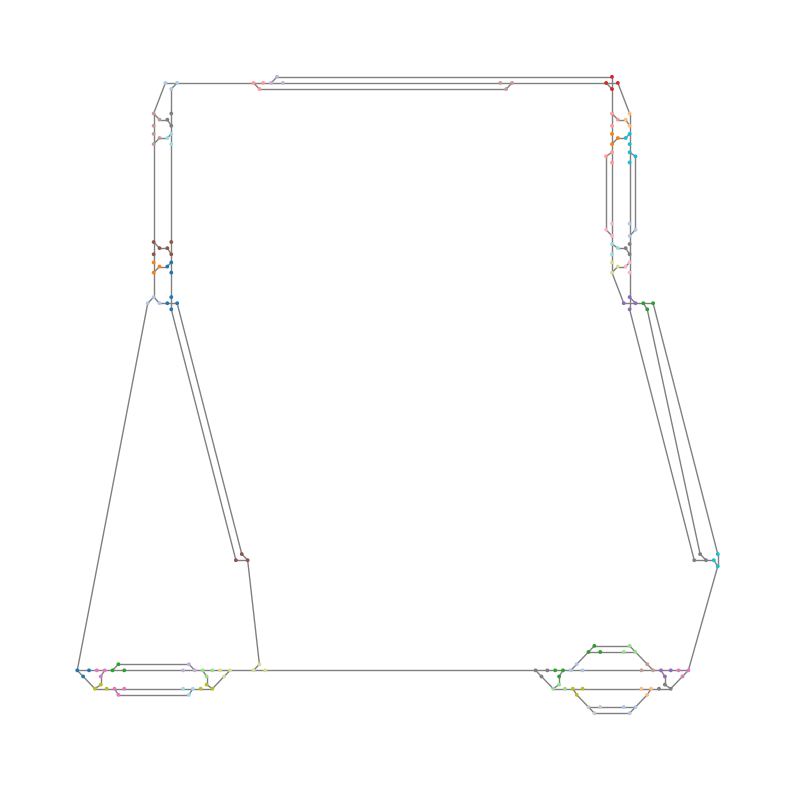

In [93]:
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(
    graph.to_undirected(),
    pos,
    with_labels=False,
    node_color=dict(graph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=3,
    ax=ax
)



In [ ]:
    nx.draw(nx.ego_graph(graph, (39.2   , 27.2), 3), pos, with_labels=True)

NodeNotFound: Source (39.2, 27.2) is not in G